# WRDS Corporate Bond Relative Value Assignment

This analysis uses the supplied WRDS enhanced end-of-month files to study relative value across the bonds of six large corporate issuers.

The main steps are as follows:

1. Select issuers with enough bonds to cover a useful duration range.
2. Keep seniority and rating consistent within each issuer-month.
3. Apply a price-quality check before calculating returns or fitting curves.
4. Plot Treasury spread (`T_Spread`) against duration.
5. Fit a weighted issuer spread curve and classify bonds as rich or cheap from the fitting residual.
6. Build monthly long-cheap/short-rich portfolios with close to zero net DV01.
7. Test three portfolio constructions instead of relying on one arbitrary choice.
8. Compare next-month return, dollar PnL, turnover, trading-cost sensitivity, and outlier characteristics.

The main results use the cleaned sample. The unfiltered result is also retained as a data-quality sensitivity so that the effect of the excluded mark is visible rather than hidden.

To run this notebook, place the two source CSV files (`WRDS_Data-Systematic_Trading-Fall2026-1.csv` and `WRDS_Data-Systematic_Trading-Fall2026-2.csv`) in the same folder as this notebook.

## Modeling Framework

The following modeling choices are grounded in the corresponding sections of the course framework (see reference below):

- **Duration and DV01.** The relationship `dP/P = -D dy` and `D = 10,000 * DV01 / P` makes the condition `sum(position * price * duration) = 0` a natural first-order hedge against a parallel one-basis-point rate move.
- **Relative value.** The useful question is not whether a spread is high or low in isolation, but whether it is high or low relative to the same issuer's curve. Actual spread minus fitted spread is used as the signal.
- **Curve construction.** Nelson-Siegel-style curve fitting motivates this step. The model is kept transparent here, using the three permitted factors: log-duration, duration, and coupon.
- **Price reliability.** Large, actively traded issues tend to provide cleaner calibration points. TRACE dollar volume and amount outstanding are therefore used in the regression weights.
- **Accrued interest.** When WRDS total return is unavailable, the fallback includes coupon accrual using the actual number of days divided by 360.
- **Trading frictions.** Corporate bonds are not frictionless, so turnover is reported and the performance calculation is repeated under several trading-cost assumptions.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

## Parameters

AAPL, AMZN, BA, CAT, DIS, and T are selected because each issuer has enough observations to form a monthly curve across a meaningful duration range. The common sample runs from August 2022 through March 2025.

A high-quality issue is characterized by at least one year to maturity and roughly $200 million outstanding; the same starting screen is used here. The WRDS amount fields are reported in thousands, so `200_000` corresponds to about $200 million.

In [2]:
DATA_DIR = Path(".")  # CSVs are committed at the repo root
CSV_FILES = [
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-1.csv",
    DATA_DIR / "WRDS_Data-Systematic_Trading-Fall2026-2.csv",
]

SELECTED_ISSUERS = ["AAPL", "AMZN", "BA", "CAT", "DIS", "T"]
START_DATE = "2022-08-31"
END_DATE = "2025-03-31"

MIN_BONDS_PER_FIT = 8
TOP_N_PER_SIDE = 3
ANALYSIS_DATE = None  # None chooses the latest common date with enough fitted bonds.

USE_VOLUME_WEIGHTS = True
MIN_TMT_YEARS = 1.0
MIN_AMOUNT_OUTSTANDING = 200_000  # WRDS field is in thousands: approximately $200 million.
SPREAD_BPS_LIMIT = (-100, 2_000)
DURATION_LIMIT = (0.05, 35.0)
PRICE_LIMIT = (20.0, 200.0)

# Ex-post data-quality screen for an isolated month-end mark. A row is flagged only
# when the price moves by more than 40% from both adjacent monthly observations,
# while the adjacent observations remain within 20% of one another.
ISOLATED_MARK_MOVE = 0.40
NEIGHBOR_PRICE_TOLERANCE = 0.20

GROSS_CAPITAL_USD = 1_000_000
TRANSACTION_COST_BPS = [0, 10, 25, 50]

missing_files = [str(p) for p in CSV_FILES if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing data files: {missing_files}")

print("Input files:")
for p in CSV_FILES:
    print(f"  {p} ({p.stat().st_size / 1_000_000:.1f} MB)")

Input files:
  WRDS_Data-Systematic_Trading-Fall2026-1.csv (10.0 MB)
  WRDS_Data-Systematic_Trading-Fall2026-2.csv (11.6 MB)


## Helper Functions

The WRDS download stores several numeric fields as strings with percent signs, dollar signs, or commas. The functions below convert them to numeric values and keep the original data logic visible.

In [3]:
def parse_percent_to_decimal(value):
    """Convert strings such as '.3171%' or '0.10%' to decimal returns/rates."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    if s.endswith("%"):
        s = s[:-1]
        try:
            return float(s) / 100.0
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_money(value):
    """Convert strings such as '$22,122,786' to floats."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).strip().replace("$", "").replace(",", "")
    if s in {"", ".", "nan", "NaN", "NR"}:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan


def weighted_std(values, weights=None):
    values = np.asarray(values, dtype=float)
    good = np.isfinite(values)
    if weights is None:
        return np.nanstd(values[good], ddof=1) if good.sum() > 1 else np.nan
    weights = np.asarray(weights, dtype=float)
    good = good & np.isfinite(weights) & (weights > 0)
    if good.sum() <= 1:
        return np.nan
    avg = np.average(values[good], weights=weights[good])
    var = np.average((values[good] - avg) ** 2, weights=weights[good])
    return np.sqrt(var)


def choose_mode(series):
    clean = series.dropna()
    if clean.empty:
        return np.nan
    return clean.mode().iloc[0]


def make_weights(group):
    if not USE_VOLUME_WEIGHTS:
        return np.ones(len(group))
    base = group["T_DVolume_num"].copy()
    fallback = group["AMOUNT_OUTSTANDING"].copy()
    base = base.where(base > 0, fallback)
    w = np.sqrt(base.clip(lower=0))
    if w.notna().sum() == 0 or w.fillna(0).sum() <= 0:
        return np.ones(len(group))
    lo, hi = w.dropna().quantile([0.05, 0.95])
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        w = w.clip(lower=lo, upper=hi)
    return w.fillna(w.median()).to_numpy()

## Load, Validate, and Clean Data

The following steps are applied before calculating returns or fitting the issuer curves:

- Convert the WRDS text fields to numeric spreads, returns, prices, and trading volumes.
- Remove defaulted and convertible observations, bonds with less than one year remaining, small issues, and implausible prices or spreads.
- Within each issuer-month, keep the most common `SECURITY_LEVEL` and `RATING_CAT`. This avoids comparing senior and subordinated debt or mixing rating groups in the same curve.
- Flag an isolated month-end price mark when it differs by more than 40% from both adjacent monthly prices while those neighboring prices remain within 20% of one another.
- Remove the flagged mark before constructing next-month returns and before fitting the spread curves.
- Show both the exclusion audit and the number of observations remaining after each step.

The two-sided price check is an ex-post data-quality procedure, not a trading signal. It flags one observation: Apple CUSIP `037833BX7` on February 28, 2025, when the recorded price temporarily falls from roughly 92 to 25 and then returns to roughly 92. An unfiltered backtest is retained solely to show how much this mark affected the original result.

The files do not contain a complete call schedule, bid-offer spread, 144A flag, subsidiary mapping, or fixed-versus-step-up coupon flag. These missing fields are not inferred and remain limitations of the analysis.

In [4]:
usecols = [
    "DATE", "ISSUE_ID", "CUSIP", "bond_sym_id", "ISIN", "company_symbol",
    "BOND_TYPE", "SECURITY_LEVEL", "CONV", "OFFERING_DATE", "OFFERING_AMT",
    "PRINCIPAL_AMT", "MATURITY", "COUPON", "AMOUNT_OUTSTANDING",
    "R_SP", "R_MR", "R_FR", "RATING_NUM", "RATING_CAT", "RATING_CLASS",
    "T_DATE", "T_Volume", "T_DVolume", "T_Spread", "T_Yld_Pt", "YIELD",
    "PRICE_EOM", "COUPAMT", "COUPACC", "RET_EOM", "TMT", "DURATION",
    "DEFAULTED",
]

raw = pd.concat([pd.read_csv(path, usecols=usecols) for path in CSV_FILES], ignore_index=True)

df = raw.copy()
date_cols = ["DATE", "OFFERING_DATE", "MATURITY", "T_DATE"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["T_Spread_dec"] = df["T_Spread"].map(parse_percent_to_decimal)
df["T_Spread_bps"] = df["T_Spread_dec"] * 10_000
df["YIELD_dec"] = df["YIELD"].map(parse_percent_to_decimal)
df["RET_EOM_dec"] = df["RET_EOM"].map(parse_percent_to_decimal)
df["T_DVolume_num"] = df["T_DVolume"].map(parse_money)
df["T_Volume_num"] = df["T_Volume"].map(parse_money)

numeric_cols = [
    "ISSUE_ID", "OFFERING_AMT", "PRINCIPAL_AMT", "COUPON",
    "AMOUNT_OUTSTANDING", "RATING_NUM", "T_Yld_Pt", "PRICE_EOM",
    "COUPAMT", "COUPACC", "TMT", "DURATION",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

selected = df[
    df["company_symbol"].isin(SELECTED_ISSUERS)
    & (df["DATE"] >= pd.Timestamp(START_DATE))
    & (df["DATE"] <= pd.Timestamp(END_DATE))
].copy()

funnel = [("Selected issuers and dates", len(selected))]
quality_mask = (
    (selected["DEFAULTED"].fillna("N") != "Y")
    & (selected["CONV"].fillna(0) == 0)
    & selected["T_Spread_bps"].between(*SPREAD_BPS_LIMIT)
    & selected["DURATION"].between(*DURATION_LIMIT)
    & selected["PRICE_EOM"].between(*PRICE_LIMIT)
    & (selected["TMT"] >= MIN_TMT_YEARS)
    & (selected["AMOUNT_OUTSTANDING"] >= MIN_AMOUNT_OUTSTANDING)
    & selected["COUPON"].notna()
)
selected = selected[quality_mask].copy()
funnel.append(("Market and high-quality calibration filters", len(selected)))

selected["modal_security_level"] = selected.groupby(["company_symbol", "DATE"])["SECURITY_LEVEL"].transform(choose_mode)
selected["modal_rating_cat"] = selected.groupby(["company_symbol", "DATE"])["RATING_CAT"].transform(choose_mode)

filtered = selected[
    (selected["SECURITY_LEVEL"] == selected["modal_security_level"])
    & (selected["RATING_CAT"] == selected["modal_rating_cat"])
].copy()
funnel.append(("Consistent seniority and rating", len(filtered)))

# Preserve the pre-QC sample for the explicit sensitivity comparison.
filtered_unchecked = filtered.sort_values(["ISSUE_ID", "DATE"]).reset_index(drop=True).copy()

price_qc = filtered_unchecked.copy()
price_qc["previous_date_qc"] = price_qc.groupby("ISSUE_ID")["DATE"].shift(1)
price_qc["next_date_qc"] = price_qc.groupby("ISSUE_ID")["DATE"].shift(-1)
price_qc["previous_price_qc"] = price_qc.groupby("ISSUE_ID")["PRICE_EOM"].shift(1)
price_qc["next_price_qc"] = price_qc.groupby("ISSUE_ID")["PRICE_EOM"].shift(-1)

previous_gap = (price_qc["DATE"] - price_qc["previous_date_qc"]).dt.days
next_gap = (price_qc["next_date_qc"] - price_qc["DATE"]).dt.days
price_qc["move_from_previous"] = (price_qc["PRICE_EOM"] / price_qc["previous_price_qc"] - 1).abs()
price_qc["move_to_next"] = (price_qc["next_price_qc"] / price_qc["PRICE_EOM"] - 1).abs()
price_qc["neighbor_price_gap"] = (price_qc["next_price_qc"] / price_qc["previous_price_qc"] - 1).abs()
price_qc["isolated_price_mark"] = (
    previous_gap.between(25, 45)
    & next_gap.between(25, 45)
    & (price_qc["move_from_previous"] > ISOLATED_MARK_MOVE)
    & (price_qc["move_to_next"] > ISOLATED_MARK_MOVE)
    & (price_qc["neighbor_price_gap"] < NEIGHBOR_PRICE_TOLERANCE)
)

price_mark_exclusions = price_qc.loc[price_qc["isolated_price_mark"], [
    "company_symbol", "CUSIP", "DATE", "previous_date_qc", "next_date_qc",
    "previous_price_qc", "PRICE_EOM", "next_price_qc", "YIELD_dec", "T_Spread_bps",
    "move_from_previous", "move_to_next", "neighbor_price_gap",
]].copy()

filtered = price_qc.loc[~price_qc["isolated_price_mark"]].drop(columns=[
    "previous_date_qc", "next_date_qc", "previous_price_qc", "next_price_qc",
    "move_from_previous", "move_to_next", "neighbor_price_gap", "isolated_price_mark",
]).copy()
funnel.append(("Isolated month-end price marks excluded", len(filtered)))

for frame in (filtered, filtered_unchecked):
    frame.sort_values(["company_symbol", "DATE", "ISSUE_ID"], inplace=True)
    frame.reset_index(drop=True, inplace=True)
    frame["month"] = frame["DATE"].dt.to_period("M")
    frame["bond_age_years"] = (frame["DATE"] - frame["OFFERING_DATE"]).dt.days / 365.25

display(pd.DataFrame(funnel, columns=["cleaning_step", "rows"]).assign(
    share_of_initial=lambda x: x["rows"] / x["rows"].iloc[0]
).style.format({"share_of_initial": "{:.1%}"}))

display(
    price_mark_exclusions.style.format({
        "previous_price_qc": "{:.2f}", "PRICE_EOM": "{:.2f}", "next_price_qc": "{:.2f}",
        "YIELD_dec": "{:.2%}", "T_Spread_bps": "{:.1f} bps",
        "move_from_previous": "{:.1%}", "move_to_next": "{:.1%}",
        "neighbor_price_gap": "{:.1%}",
    })
)

display(
    filtered.groupby("company_symbol").agg(
        rows=("ISSUE_ID", "size"),
        bonds=("ISSUE_ID", "nunique"),
        first_date=("DATE", "min"),
        last_date=("DATE", "max"),
        median_duration=("DURATION", "median"),
        duration_min=("DURATION", "min"),
        duration_max=("DURATION", "max"),
        median_spread_bps=("T_Spread_bps", "median"),
    )
)

,cleaning_step,rows,share_of_initial
0,Selected issuers and dates,10689,100.0%
1,Market and high-quality calibration filters,7569,70.8%
2,Consistent seniority and rating,7559,70.7%
3,Isolated month-end price marks excluded,7558,70.7%


,company_symbol,CUSIP,DATE,previous_date_qc,next_date_qc,previous_price_qc,PRICE_EOM,next_price_qc,YIELD_dec,T_Spread_bps,move_from_previous,move_to_next,neighbor_price_gap
1322,AAPL,037833BX7,2025-02-28 00:00:00,2025-01-31 00:00:00,2025-03-31 00:00:00,91.76,25.17,92.24,19.66%,466.0 bps,72.6%,266.5%,0.5%


,rows,bonds,first_date,last_date,median_duration,duration_min,duration_max,median_spread_bps
company_symbol,,,,,,,,
AAPL,1474,52,2022-08-31,2025-03-31,7.3150,0.9500,20.9900,19.0000
AMZN,908,33,2022-08-31,2025-03-31,6.5800,0.9500,20.0300,15.0000
BA,1304,51,2022-08-31,2025-03-31,7.3950,0.9200,16.4100,28.5000
CAT,957,51,2022-08-31,2025-03-31,3.4500,0.9500,18.6500,13.0000
DIS,1237,44,2022-08-31,2025-03-31,8.8200,0.9600,18.1900,20.0000
T,1678,56,2022-08-31,2025-03-31,10.6300,0.9600,17.8400,28.0000


In [5]:
consistency_check = filtered.groupby(["company_symbol", "DATE"]).agg(
    security_levels=("SECURITY_LEVEL", "nunique"),
    rating_cats=("RATING_CAT", "nunique"),
    bonds=("ISSUE_ID", "nunique"),
).reset_index()

print("Consistency-filter check. The first two columns should be 1 for every issuer-month.")
display(consistency_check[["security_levels", "rating_cats", "bonds"]].describe())

Consistency-filter check. The first two columns should be 1 for every issuer-month.


,security_levels,rating_cats,bonds
count,192.0000,192.0000,192.0000
mean,1.0000,1.0000,39.3646
std,0.0000,0.0000,8.7772
min,1.0000,1.0000,24.0000
25%,1.0000,1.0000,31.0000
50%,1.0000,1.0000,40.0000
75%,1.0000,1.0000,47.0000
max,1.0000,1.0000,54.0000


## Next-Month Return and Accrued Interest

The isolated February 2025 Apple price mark is removed before shifting prices and returns. This step is important because leaving it in place would contaminate both the January-to-February short return and the February-to-March long return. After the exclusion, the January observation jumps directly to March, a 59-day gap, so the existing 25-to-45-day rule correctly marks that transition unavailable rather than inventing a two-month return.

Positions are formed at month-end and evaluated using the next observation for the same bond when the gap is between 25 and 45 days.

`RET_EOM` is the preferred measure because it is the WRDS enhanced monthly total return. If it is missing, the clean-price return and accrued coupon are used instead. For that fallback, accrual is calculated using an actual/360 day-count convention: `annual coupon rate * gap days / 360`.

In [6]:
def add_next_month_returns(data):
    result = data.sort_values(["ISSUE_ID", "DATE"]).copy()
    result["next_date"] = result.groupby("ISSUE_ID")["DATE"].shift(-1)
    result["next_price"] = result.groupby("ISSUE_ID")["PRICE_EOM"].shift(-1)
    result["next_ret_eom"] = result.groupby("ISSUE_ID")["RET_EOM_dec"].shift(-1)

    gap_days = (result["next_date"] - result["DATE"]).dt.days
    valid_next_month = gap_days.between(25, 45)

    approx_price_return = (result["next_price"] - result["PRICE_EOM"]) / result["PRICE_EOM"]
    coupon_accrual_30_360 = (result["COUPON"] / 100.0) * gap_days / 360.0
    result["next_ret_approx_with_accrual"] = approx_price_return + coupon_accrual_30_360

    result["next_return"] = np.where(
        valid_next_month,
        result["next_ret_eom"].where(result["next_ret_eom"].notna(), result["next_ret_approx_with_accrual"]),
        np.nan,
    )
    result["next_return_source"] = np.where(
        valid_next_month & result["next_ret_eom"].notna(),
        "RET_EOM",
        np.where(valid_next_month & result["next_ret_approx_with_accrual"].notna(), "price_plus_accrual_30_360", "unavailable"),
    )
    return result


filtered = add_next_month_returns(filtered)
filtered_unchecked = add_next_month_returns(filtered_unchecked)

display(filtered["next_return_source"].value_counts(dropna=False).to_frame("rows"))

,rows
next_return_source,
RET_EOM,7224
unavailable,334


## Spread Curve Model

For each issuer-month, the following specification is estimated:

`T_Spread_bps = b0 + b1 * log(1 + DURATION) + b2 * DURATION + b3 * COUPON`

This specification is chosen because it is easy to interpret while still allowing the spread curve to bend with duration. Duration also matches the variable used later in the hedge. Coupon absorbs some systematic cash-flow and price differences that would otherwise appear in the residual.

A curve can be distorted by stale or thinly traded bonds. TRACE dollar volume and amount outstanding are therefore combined in the weighted least-squares fit, then winsorized within each issuer-month so that one very large issue does not control the result. Weighted RMSE and weighted R-squared provide a quick check on whether the fitted curve is doing a reasonable job.

In [7]:
def fit_curve_one_group(group):
    group = group.copy()
    group["fit_ok"] = False
    group["spread_fit_bps"] = np.nan
    group["resid_bps"] = np.nan
    group["resid_z"] = np.nan
    group["fit_weight"] = np.nan

    fit_group = group.dropna(subset=["T_Spread_bps", "DURATION", "COUPON", "PRICE_EOM"])
    if len(fit_group) < MIN_BONDS_PER_FIT:
        return group, None

    X = np.column_stack([
        np.log1p(fit_group["DURATION"].to_numpy()),
        fit_group["DURATION"].to_numpy(),
        fit_group["COUPON"].to_numpy(),
    ])
    y = fit_group["T_Spread_bps"].to_numpy()

    volume_weight = make_weights(fit_group)
    issue_size = fit_group["AMOUNT_OUTSTANDING"].fillna(fit_group["AMOUNT_OUTSTANDING"].median()).clip(lower=1)
    lo_size, hi_size = issue_size.quantile([0.10, 0.90])
    size_weight = np.sqrt(issue_size.clip(lo_size, hi_size) / issue_size.clip(lo_size, hi_size).median())
    weights = np.asarray(volume_weight) * np.asarray(size_weight)
    weights = weights / np.nanmean(weights)

    if np.unique(np.round(y, 8)).size < 2:
        return group, None

    model = LinearRegression()
    model.fit(X, y, sample_weight=weights)
    pred = model.predict(X)
    resid = y - pred
    resid_scale = weighted_std(resid, weights)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = np.nanstd(resid, ddof=1)
    if not np.isfinite(resid_scale) or resid_scale <= 0:
        resid_scale = 1.0

    idx = fit_group.index
    group.loc[idx, "fit_ok"] = True
    group.loc[idx, "spread_fit_bps"] = pred
    group.loc[idx, "resid_bps"] = resid
    group.loc[idx, "resid_z"] = resid / resid_scale
    group.loc[idx, "fit_weight"] = weights

    stats = {
        "company_symbol": fit_group["company_symbol"].iloc[0],
        "DATE": fit_group["DATE"].iloc[0],
        "n_bonds": len(fit_group),
        "r2": model.score(X, y, sample_weight=weights),
        "weighted_rmse_bps": np.sqrt(np.average(resid ** 2, weights=weights)),
        "b0": model.intercept_,
        "b_log_duration": model.coef_[0],
        "b_duration": model.coef_[1],
        "b_coupon": model.coef_[2],
        "resid_std_bps": resid_scale,
    }
    return group, stats


def fit_all_curves(data):
    fit_parts = []
    stats_rows = []
    for _, group in data.groupby(["company_symbol", "DATE"], sort=True):
        fitted_group, stats = fit_curve_one_group(group)
        fit_parts.append(fitted_group)
        if stats is not None:
            stats_rows.append(stats)
    return pd.concat(fit_parts, ignore_index=True), pd.DataFrame(stats_rows)


fitted, model_stats = fit_all_curves(filtered)
fitted_unchecked, model_stats_unchecked = fit_all_curves(filtered_unchecked)

display(
    model_stats.groupby("company_symbol").agg(
        fit_months=("DATE", "nunique"),
        avg_bonds=("n_bonds", "mean"),
        median_r2=("r2", "median"),
        median_weighted_rmse_bps=("weighted_rmse_bps", "median"),
        median_resid_std_bps=("resid_std_bps", "median"),
    ).style.format({
        "avg_bonds": "{:.1f}", "median_r2": "{:.3f}",
        "median_weighted_rmse_bps": "{:.1f}", "median_resid_std_bps": "{:.1f}",
    })
)

,fit_months,avg_bonds,median_r2,median_weighted_rmse_bps,median_resid_std_bps
company_symbol,,,,,
AAPL,32,46.1,0.746,6.2,6.2
AMZN,32,28.4,0.755,5.3,5.3
BA,32,40.8,0.376,10.5,10.5
CAT,32,29.9,0.617,7.1,7.1
DIS,32,38.7,0.535,8.4,8.4
T,32,52.4,0.386,12.8,12.8


In [8]:
if ANALYSIS_DATE is None:
    common_dates = (
        model_stats.groupby("DATE")["company_symbol"]
        .nunique()
        .loc[lambda s: s >= len(SELECTED_ISSUERS)]
    )
    if common_dates.empty:
        common_dates = model_stats.groupby("DATE")["company_symbol"].nunique().loc[lambda s: s >= 4]
    analysis_date = common_dates.index.max()
else:
    analysis_date = pd.Timestamp(ANALYSIS_DATE)

print(f"Analysis date for cross-sectional plots: {analysis_date.date()}")
display(
    model_stats[model_stats["DATE"].eq(analysis_date)]
    .sort_values("company_symbol")
    [["company_symbol", "n_bonds", "r2", "resid_std_bps", "b0", "b_log_duration", "b_duration", "b_coupon"]]
)

Analysis date for cross-sectional plots: 2025-03-31


,company_symbol,n_bonds,r2,resid_std_bps,b0,b_log_duration,b_duration,b_coupon
31,AAPL,41,0.7634,4.3080,8.2800,-0.9932,1.4655,-0.9608
63,AMZN,24,0.7484,4.0214,9.9781,-4.6242,1.7663,-0.5321
95,BA,40,0.3139,7.6989,16.5833,0.3325,1.1630,-1.6616
127,CAT,30,0.6063,4.3097,-1.9559,10.4093,-0.3695,-0.3732
159,DIS,33,0.6087,5.6568,-0.6256,0.5547,1.2801,1.6156
191,T,51,0.5870,7.4134,3.4247,-8.6979,2.5332,2.7872


## Spread vs. Duration by Issuer

The scatter points are individual bonds on the selected analysis date. The line is the fitted curve from the cross-sectional model for that issuer-month.

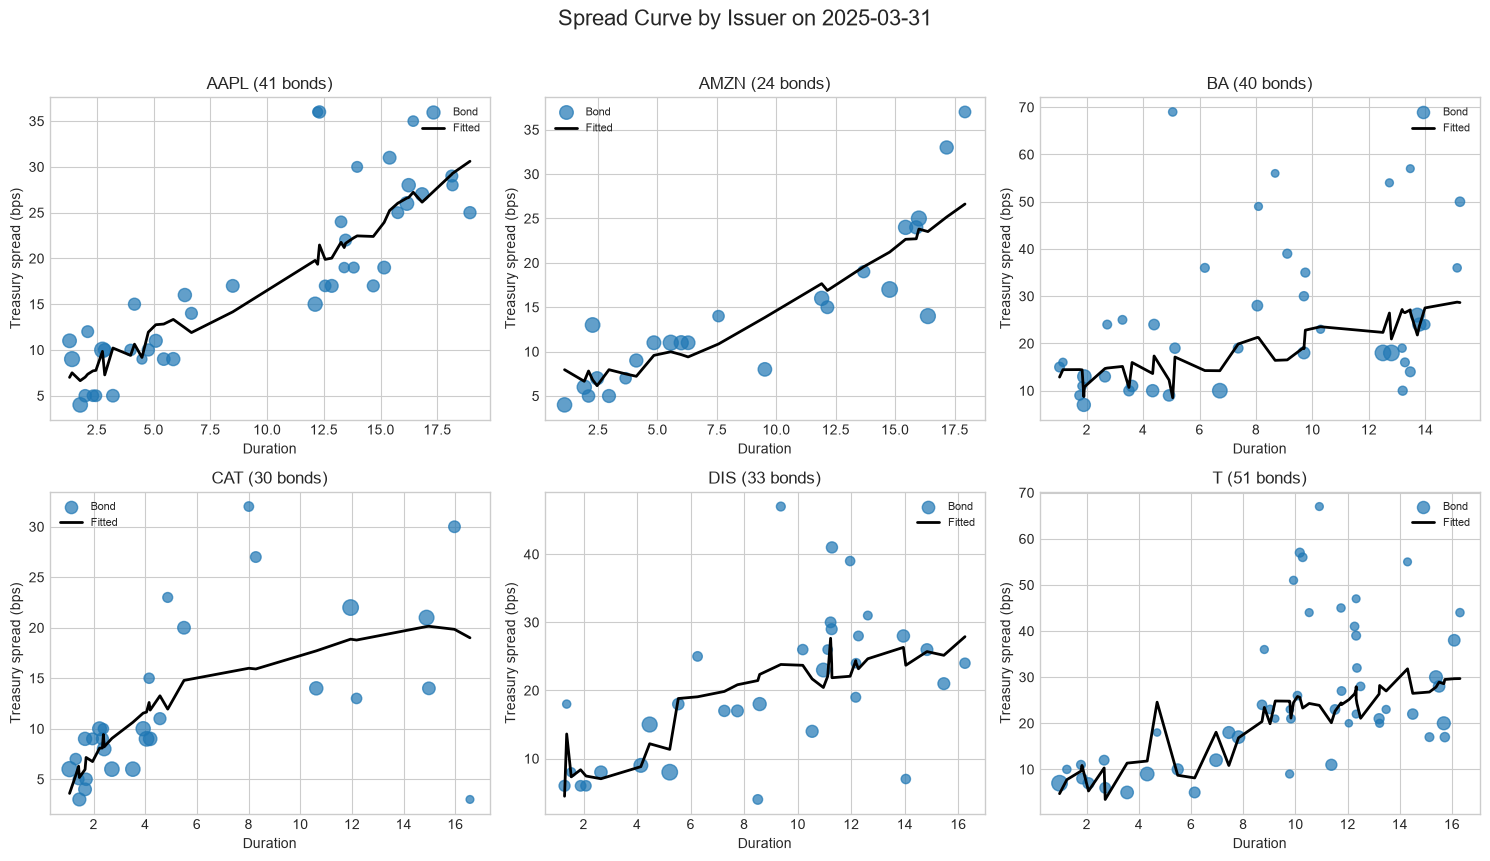

In [9]:
plot_df = fitted[(fitted["DATE"] == analysis_date) & fitted["fit_ok"]].copy()

n_issuers = len(SELECTED_ISSUERS)
ncols = 3
nrows = int(np.ceil(n_issuers / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = plot_df[plot_df["company_symbol"] == issuer].sort_values("DURATION")
    if g.empty:
        ax.set_title(f"{issuer}: no fitted data")
        ax.axis("off")
        continue
    size = np.sqrt(g["T_DVolume_num"].fillna(0).clip(lower=0))
    if size.max() > 0:
        size = 25 + 100 * size / size.max()
    else:
        size = 45
    ax.scatter(g["DURATION"], g["T_Spread_bps"], s=size, alpha=0.70, label="Bond")
    ax.plot(g["DURATION"], g["spread_fit_bps"], color="black", linewidth=2.0, label="Fitted")
    ax.set_title(f"{issuer} ({len(g)} bonds)")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Treasury spread (bps)")
    ax.legend(loc="best", fontsize=8)

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Spread Curve by Issuer on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Rich and Cheap Bonds

Residuals are measured as actual spread minus fitted spread:

- Positive residual: the bond trades wider than the curve and is classified as cheap.
- Negative residual: the bond trades tighter than the curve and is classified as rich.

The table below shows the most extreme residuals on the analysis date.

In [10]:
snapshot = plot_df.copy()
snapshot["rich_cheap"] = np.where(snapshot["resid_bps"] > 0, "cheap", "rich")
outlier_table = (
    snapshot.assign(abs_resid=lambda x: x["resid_bps"].abs())
    .sort_values(["company_symbol", "abs_resid"], ascending=[True, False])
    .groupby("company_symbol")
    .head(6)
    [[
        "company_symbol", "CUSIP", "MATURITY", "SECURITY_LEVEL", "RATING_CAT",
        "COUPON", "DURATION", "TMT", "PRICE_EOM", "T_Spread_bps",
        "spread_fit_bps", "resid_bps", "resid_z", "rich_cheap",
        "T_DVolume_num", "AMOUNT_OUTSTANDING",
    ]]
    .sort_values(["company_symbol", "resid_bps"], ascending=[True, False])
)
display(outlier_table)

,company_symbol,CUSIP,MATURITY,SECURITY_LEVEL,RATING_CAT,COUPON,DURATION,TMT,PRICE_EOM,T_Spread_bps,spread_fit_bps,resid_bps,resid_z,rich_cheap,T_DVolume_num,AMOUNT_OUTSTANDING
1434,AAPL,037833AT7,2044-05-06,SEN,AA,4.4500,12.2300,19.3800,92.2900,36.0000,19.3625,16.6375,3.8620,cheap,"20,807,341.0000","1,000,000.0000"
1459,AAPL,037833EE6,2041-02-08,SEN,AA,2.3750,12.3100,16.0900,70.2400,36.0000,21.4675,14.5325,3.3734,cheap,"79,582,495.0000","1,500,000.0000"
1455,AAPL,037833DZ0,2050-08-20,SEN,AA,2.4000,16.4400,25.7600,59.8700,35.0000,27.2275,7.7725,1.8042,cheap,"28,309,879.0000","1,250,000.0000"
1446,AAPL,037833DD9,2047-09-12,SEN,AA,3.7500,13.9700,22.7800,79.2100,30.0000,22.4623,7.5377,1.7497,cheap,"34,407,947.0000","1,000,000.0000"
1451,AAPL,037833DQ0,2049-09-11,SEN,AA,2.9500,15.4000,24.8100,67.5900,31.0000,25.2360,5.7640,1.3380,cheap,"97,827,660.0000","1,500,000.0000"
1456,AAPL,037833EA4,2060-08-20,SEN,AA,2.5500,18.9400,35.9100,59.0600,25.0000,30.6141,-5.6141,-1.3032,rich,"72,485,993.0000","1,750,000.0000"
2367,AMZN,023135BU9,2060-06-03,SEN,AA,2.7000,17.9400,35.6900,58.0300,37.0000,26.6284,10.3716,2.5791,cheap,"49,920,298.0000","2,000,000.0000"
2371,AMZN,023135CC8,2061-05-12,SEN,AA,3.2500,17.1700,36.6400,65.8200,33.0000,25.1675,7.8325,1.9477,cheap,"104,931,881.0000","1,750,000.0000"
2360,AMZN,023135BC9,2027-08-22,SEN,AA,3.1500,2.2700,2.4300,97.7800,13.0000,6.8327,6.1673,1.5336,cheap,"183,378,367.0000","3,500,000.0000"
2377,AMZN,023135CJ3,2052-04-13,SEN,AA,3.9500,14.7700,27.4300,79.5000,17.0000,21.2109,-4.2109,-1.0471,rich,"259,636,243.0000","2,500,000.0000"


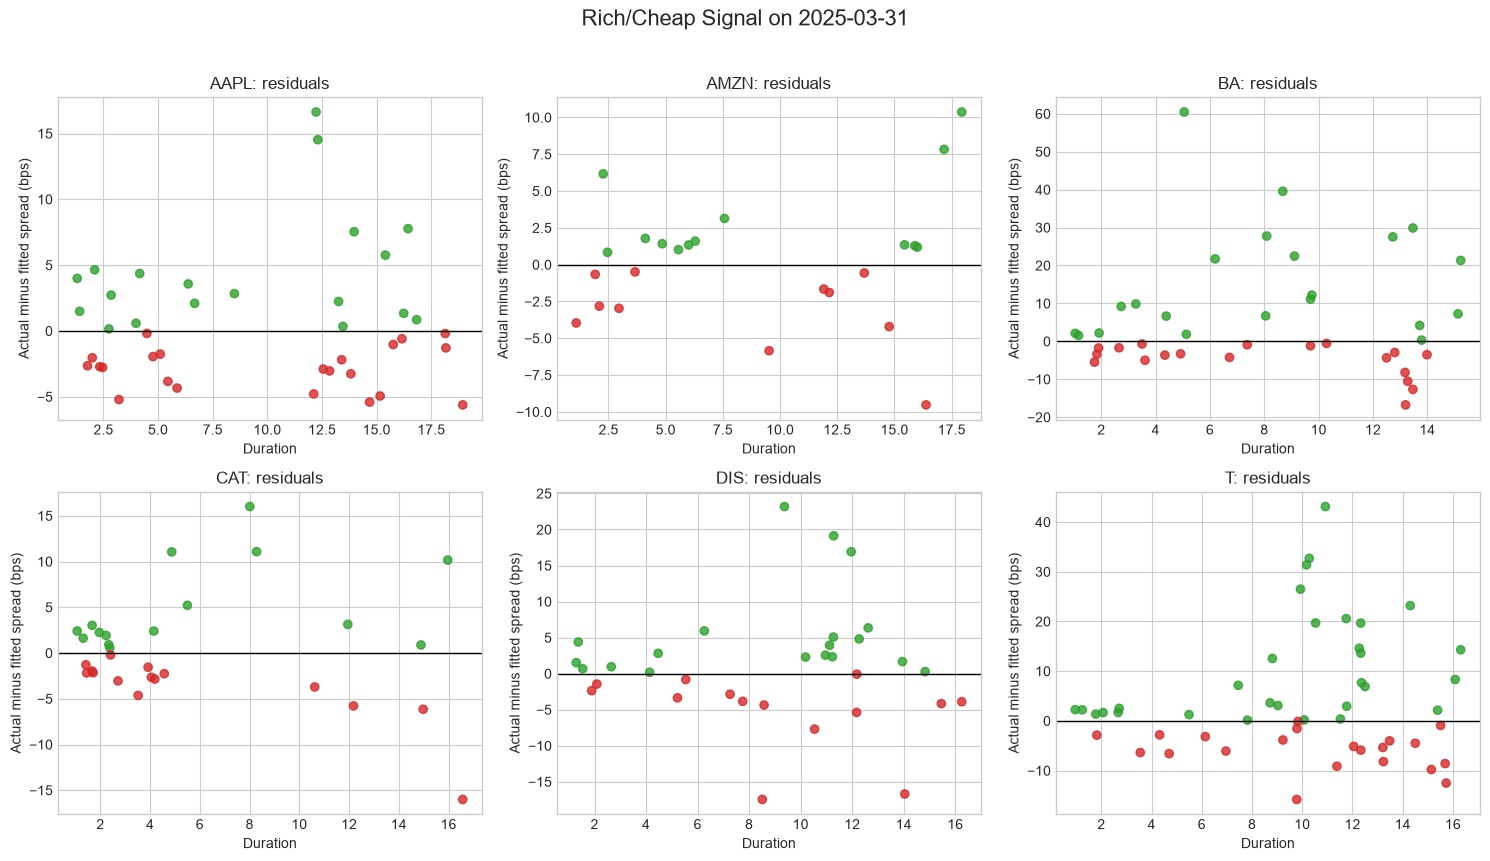

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.2 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, issuer in zip(axes, SELECTED_ISSUERS):
    g = snapshot[snapshot["company_symbol"] == issuer].copy()
    if g.empty:
        ax.axis("off")
        continue
    colors = np.where(g["resid_bps"] >= 0, "tab:green", "tab:red")
    ax.axhline(0, color="black", linewidth=1)
    ax.scatter(g["DURATION"], g["resid_bps"], c=colors, alpha=0.8)
    ax.set_title(f"{issuer}: residuals")
    ax.set_xlabel("Duration")
    ax.set_ylabel("Actual minus fitted spread (bps)")

for ax in axes[n_issuers:]:
    ax.axis("off")

fig.suptitle(f"Rich/Cheap Signal on {analysis_date.date()}", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## Three Portfolio Iterations

The portfolio step is treated as three passes. Each pass changes one economic choice, so the improvement is easier to interpret than it would be after searching a large parameter grid.

1. **Pass 1 - Baseline top 3.** The three widest and three tightest residual z-scores form the book, with position size proportional to signal strength. This is the plainest specification of the three.
2. **Pass 2 - Concentrated top 2.** The baseline may dilute the trade with weaker residuals, so only the two strongest signals on each side are kept. The expected benefit is a larger convergence payoff; the cost is more issuer-specific risk.
3. **Pass 3 - Liquidity-aware top 3.** Concentration improves the headline return but does not address implementation. In the final pass, the residual z-score is multiplied by a capped square-root measure of TRACE dollar volume relative to the issuer-month median. This favors stronger signals in bonds that appear easier to trade.

Every pass scales the short side so `sum(position * price * duration) = 0`, then normalizes gross market value to one. Since `DV01 = price * duration / 10,000`, this also makes first-order net DV01 approximately zero. It does not remove curve-shape, credit, downgrade, or liquidity risk.

In [12]:
def performance_summary(return_series):
    r = pd.Series(return_series).dropna()
    if r.empty:
        return pd.Series(dtype=float)
    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (12 / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(12) if len(r) > 1 else np.nan
    sharpe = ann_return / ann_vol if np.isfinite(ann_vol) and ann_vol > 0 else np.nan
    return pd.Series({
        "months": len(r),
        "mean_monthly_return": r.mean(),
        "monthly_volatility": r.std(ddof=1),
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "annualized_sharpe": sharpe,
        "total_return": total_return,
        "win_rate": (r > 0).mean(),
    })


def build_portfolio_one_group(group, top_n, score_col, trial_name):
    group = group.dropna(subset=[score_col, "PRICE_EOM", "DURATION", "next_return"]).copy()
    if len(group) < max(MIN_BONDS_PER_FIT, 2 * top_n):
        return pd.DataFrame()

    longs = group.nlargest(top_n, score_col).copy()
    shorts = group.nsmallest(top_n, score_col).copy()
    if set(longs.index).intersection(set(shorts.index)):
        return pd.DataFrame()

    longs["side"] = "long cheap"
    shorts["side"] = "short rich"
    port = pd.concat([longs, shorts], axis=0).copy()
    port["trial"] = trial_name
    port["portfolio_score"] = port[score_col]
    long_mask = port["side"].eq("long cheap")
    port["raw_signal"] = np.where(
        long_mask,
        port["portfolio_score"].clip(lower=0),
        (-port["portfolio_score"]).clip(lower=0),
    )
    port["raw_signal"] = port["raw_signal"].where(port["raw_signal"] > 0, 1.0)

    price_scale = port["PRICE_EOM"] / 100.0
    long_dur = (port.loc[long_mask, "raw_signal"] * price_scale.loc[long_mask] * port.loc[long_mask, "DURATION"]).sum()
    short_dur = (port.loc[~long_mask, "raw_signal"] * price_scale.loc[~long_mask] * port.loc[~long_mask, "DURATION"]).sum()
    if not np.isfinite(long_dur) or not np.isfinite(short_dur) or long_dur <= 0 or short_dur <= 0:
        return pd.DataFrame()

    short_scale = long_dur / short_dur
    port["position_face"] = np.where(long_mask, port["raw_signal"], -port["raw_signal"] * short_scale)
    gross_market_value = (port["position_face"].abs() * price_scale).sum()
    if not np.isfinite(gross_market_value) or gross_market_value <= 0:
        return pd.DataFrame()

    port["position_face"] /= gross_market_value
    port["market_weight"] = port["position_face"] * price_scale
    port["duration_contribution"] = port["market_weight"] * port["DURATION"]
    port["dv01_usd"] = port["duration_contribution"] * GROSS_CAPITAL_USD / 10_000
    port["return_contribution"] = port["market_weight"] * port["next_return"]
    port["pnl_usd"] = port["return_contribution"] * GROSS_CAPITAL_USD
    return port


def calculate_turnover(pos):
    frames = []
    for issuer, group in pos.groupby("company_symbol"):
        pivot = (
            group.pivot_table(index="DATE", columns="ISSUE_ID", values="market_weight", aggfunc="sum")
            .sort_index()
            .fillna(0.0)
        )
        turnover = 0.5 * pivot.diff().abs().sum(axis=1)
        turnover.iloc[0] = np.nan
        frames.append(pd.DataFrame({"company_symbol": issuer, "DATE": turnover.index, "turnover": turnover.values}))
    return pd.concat(frames, ignore_index=True)


def run_portfolio_trial(trial_name, top_n, score_col, fitted_data):
    parts = []
    for _, group in fitted_data.groupby(["company_symbol", "DATE"], sort=True):
        trial_positions = build_portfolio_one_group(group, top_n, score_col, trial_name)
        if not trial_positions.empty:
            parts.append(trial_positions)
    positions_trial = pd.concat(parts, ignore_index=True)

    issuer_trial = (
        positions_trial.groupby(["company_symbol", "DATE"])
        .agg(
            portfolio_return=("return_contribution", "sum"),
            pnl_usd=("pnl_usd", "sum"),
            gross_market_value=("market_weight", lambda x: x.abs().sum()),
            net_market_value=("market_weight", "sum"),
            portfolio_duration=("duration_contribution", "sum"),
            net_dv01_usd=("dv01_usd", "sum"),
            gross_dv01_usd=("dv01_usd", lambda x: x.abs().sum()),
            n_positions=("ISSUE_ID", "size"),
            avg_abs_resid_bps=("resid_bps", lambda x: x.abs().mean()),
        )
        .reset_index()
    )
    issuer_trial = issuer_trial.merge(calculate_turnover(positions_trial), on=["company_symbol", "DATE"], how="left")

    combined_trial = (
        issuer_trial.groupby("DATE")
        .agg(
            portfolio_return=("portfolio_return", "mean"),
            pnl_usd=("pnl_usd", "mean"),
            turnover=("turnover", "mean"),
            portfolio_duration=("portfolio_duration", "mean"),
            net_dv01_usd=("net_dv01_usd", "mean"),
            issuers=("company_symbol", "nunique"),
        )
        .reset_index()
    )
    for cost_bps in TRANSACTION_COST_BPS:
        combined_trial[f"net_return_{cost_bps}bps"] = (
            combined_trial["portfolio_return"] - combined_trial["turnover"].fillna(0) * cost_bps / 10_000
        )
    return positions_trial, issuer_trial, combined_trial


def add_liquidity_scores(data):
    result = data.copy()
    result["volume_ratio"] = (
        result["T_DVolume_num"] /
        result.groupby(["company_symbol", "DATE"])["T_DVolume_num"].transform("median")
    )
    result["liquidity_multiplier"] = np.sqrt(result["volume_ratio"].clip(0.25, 4.0))
    result["liquidity_score"] = result["resid_z"] * result["liquidity_multiplier"]
    return result


fitted = add_liquidity_scores(fitted)
fitted_unchecked = add_liquidity_scores(fitted_unchecked)

TRIAL_CONFIGS = {
    "Pass 1 - Baseline top 3": {"top_n": 3, "score_col": "resid_z"},
    "Pass 2 - Concentrated top 2": {"top_n": 2, "score_col": "resid_z"},
    "Pass 3 - Liquidity-aware top 3": {"top_n": 3, "score_col": "liquidity_score"},
}

trial_outputs = {
    name: run_portfolio_trial(name, fitted_data=fitted, **config)
    for name, config in TRIAL_CONFIGS.items()
}
raw_trial_outputs = {
    name: run_portfolio_trial(name, fitted_data=fitted_unchecked, **config)
    for name, config in TRIAL_CONFIGS.items()
}

,months,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_total_return,win_rate,average_turnover,net_25bps_annualized_return,net_25bps_sharpe,net_25bps_total_return
trial,,,,,,,,,,
Pass 1 - Baseline top 3,31,0.15%,0.78%,0.19,0.38%,51.6%,0.78,-2.10%,-2.77,-5.33%
Pass 2 - Concentrated top 2,31,0.39%,1.02%,0.38,1.00%,58.1%,0.82,-1.98%,-1.96,-5.03%
Pass 3 - Liquidity-aware top 3,31,0.10%,0.64%,0.15,0.25%,51.6%,0.79,-2.17%,-3.47,-5.50%


,raw_gross_annualized_return,cleaned_gross_annualized_return,raw_net_25bps_annualized_return,cleaned_net_25bps_annualized_return
trial,,,,
Pass 1 - Baseline top 3,2.75%,0.15%,0.45%,-2.10%
Pass 2 - Concentrated top 2,4.48%,0.39%,2.02%,-1.98%
Pass 3 - Liquidity-aware top 3,5.99%,0.10%,3.60%,-2.17%


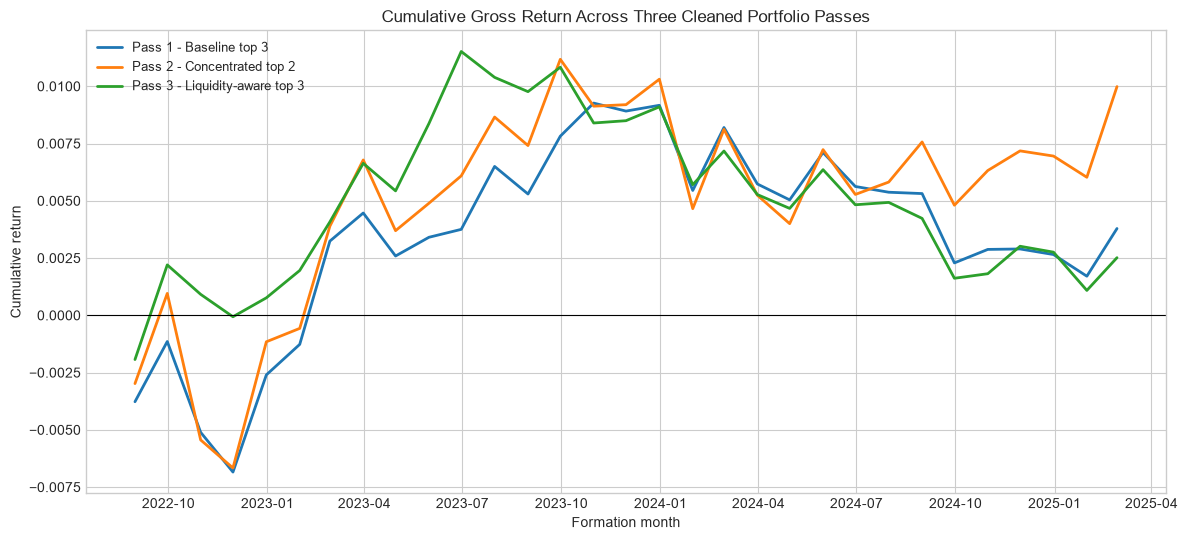

Selected portfolio after data cleaning: Pass 2 - Concentrated top 2


,annualized_return,annualized_volatility,annualized_sharpe,total_return
sample,,,,
All six issuers,0.39%,1.02%,0.38,1.00%
Excluding AAPL,0.38%,1.27%,0.30,0.99%


In [13]:
def summarize_trial_outputs(outputs):
    rows = []
    for name, (trial_positions, trial_issuer, trial_combined) in outputs.items():
        gross = performance_summary(trial_combined["portfolio_return"])
        net_25 = performance_summary(trial_combined["net_return_25bps"])
        rows.append({
            "trial": name,
            "months": gross["months"],
            "gross_annualized_return": gross["annualized_return"],
            "gross_annualized_volatility": gross["annualized_volatility"],
            "gross_sharpe": gross["annualized_sharpe"],
            "gross_total_return": gross["total_return"],
            "win_rate": gross["win_rate"],
            "average_turnover": trial_combined["turnover"].mean(),
            "net_25bps_annualized_return": net_25["annualized_return"],
            "net_25bps_sharpe": net_25["annualized_sharpe"],
            "net_25bps_total_return": net_25["total_return"],
        })
    return pd.DataFrame(rows).set_index("trial")


trial_summary = summarize_trial_outputs(trial_outputs)
raw_trial_summary = summarize_trial_outputs(raw_trial_outputs)

display(trial_summary.style.format({
    "months": "{:.0f}",
    "gross_annualized_return": "{:.2%}",
    "gross_annualized_volatility": "{:.2%}",
    "gross_sharpe": "{:.2f}",
    "gross_total_return": "{:.2%}",
    "win_rate": "{:.1%}",
    "average_turnover": "{:.2f}",
    "net_25bps_annualized_return": "{:.2%}",
    "net_25bps_sharpe": "{:.2f}",
    "net_25bps_total_return": "{:.2%}",
}))

data_quality_sensitivity = pd.DataFrame({
    "raw_gross_annualized_return": raw_trial_summary["gross_annualized_return"],
    "cleaned_gross_annualized_return": trial_summary["gross_annualized_return"],
    "raw_net_25bps_annualized_return": raw_trial_summary["net_25bps_annualized_return"],
    "cleaned_net_25bps_annualized_return": trial_summary["net_25bps_annualized_return"],
})
display(data_quality_sensitivity.style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(12, 5.5))
for name, (_, _, trial_combined) in trial_outputs.items():
    cumulative_trial = (1 + trial_combined.set_index("DATE")["portfolio_return"]).cumprod() - 1
    ax.plot(cumulative_trial.index, cumulative_trial, linewidth=2, label=name)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Cumulative Gross Return Across Three Cleaned Portfolio Passes")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Select on cleaned, cost-adjusted Sharpe, not gross return alone.
SELECTED_TRIAL = trial_summary["net_25bps_sharpe"].idxmax()
positions, issuer_month_returns, combined_returns = trial_outputs[SELECTED_TRIAL]

robustness_rows = []
for label, trial_issuer in {
    "All six issuers": issuer_month_returns,
    "Excluding AAPL": issuer_month_returns[issuer_month_returns["company_symbol"] != "AAPL"],
}.items():
    robustness_monthly = trial_issuer.groupby("DATE")["portfolio_return"].mean()
    stats = performance_summary(robustness_monthly)
    robustness_rows.append({
        "sample": label,
        "annualized_return": stats["annualized_return"],
        "annualized_volatility": stats["annualized_volatility"],
        "annualized_sharpe": stats["annualized_sharpe"],
        "total_return": stats["total_return"],
    })
robustness_table = pd.DataFrame(robustness_rows).set_index("sample")

print(f"Selected portfolio after data cleaning: {SELECTED_TRIAL}")
display(robustness_table.style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}",
}))

## What Changed Across the Three Passes

The cleaned backtest changes the conclusion. The baseline earns 0.15% annualized with 0.78% volatility. Concentrating on the two strongest signals raises gross return to 0.39% and produces the highest gross Sharpe ratio, 0.38. The liquidity-aware pass earns 0.10% with 0.64% volatility.

After a 25 bp one-way turnover charge, annualized returns are -2.10%, -1.98%, and -2.17% for Passes 1, 2, and 3. Pass 2 is selected because it has the least-negative cost-adjusted Sharpe ratio, but none of the three versions is economically attractive after costs.

The data-quality sensitivity table shows why the correction matters. The original 2.75%, 4.48%, and 5.99% gross returns were largely created by one temporary Apple price mark. Those unfiltered numbers are retained for transparency, but they are not used as the main result.

Dollar PnL below assumes `$1,000,000` of gross capital. The combined portfolio equal-weights the available issuer portfolios each month.

In [14]:
issuer_summary = issuer_month_returns.groupby("company_symbol")["portfolio_return"].apply(performance_summary).unstack()
issuer_extras = issuer_month_returns.groupby("company_symbol").agg(
    total_pnl_usd=("pnl_usd", "sum"),
    avg_turnover=("turnover", "mean"),
    avg_abs_portfolio_duration=("portfolio_duration", lambda x: x.abs().mean()),
    avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
    avg_positions=("n_positions", "mean"),
)
issuer_summary = issuer_summary.join(issuer_extras)

combined_summary = performance_summary(combined_returns["portfolio_return"]).to_frame("combined").T
combined_summary["total_pnl_usd"] = combined_returns["pnl_usd"].sum()
combined_summary["avg_turnover"] = combined_returns["turnover"].mean()
combined_summary["avg_abs_portfolio_duration"] = combined_returns["portfolio_duration"].abs().mean()
combined_summary["avg_abs_net_dv01_usd"] = combined_returns["net_dv01_usd"].abs().mean()
combined_summary["avg_positions"] = issuer_month_returns.groupby("DATE")["n_positions"].sum().mean()

summary_table = pd.concat([issuer_summary, combined_summary], axis=0)
display(summary_table.style.format({
    "mean_monthly_return": "{:.2%}", "monthly_volatility": "{:.2%}",
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}",
    "win_rate": "{:.1%}", "total_pnl_usd": "${:,.0f}",
    "avg_turnover": "{:.2f}", "avg_abs_portfolio_duration": "{:.6f}",
    "avg_abs_net_dv01_usd": "${:,.4f}", "avg_positions": "{:.1f}",
}))

cost_sensitivity = pd.DataFrame({
    f"{cost} bps": performance_summary(combined_returns[f"net_return_{cost}bps"])
    for cost in TRANSACTION_COST_BPS
}).T
display(cost_sensitivity[["annualized_return", "annualized_volatility", "annualized_sharpe", "total_return", "win_rate"]].style.format({
    "annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}",
    "annualized_sharpe": "{:.2f}", "total_return": "{:.2%}", "win_rate": "{:.1%}",
}))

,months,mean_monthly_return,monthly_volatility,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate,total_pnl_usd,avg_turnover,avg_abs_portfolio_duration,avg_abs_net_dv01_usd,avg_positions
AAPL,31.000000,0.03%,0.32%,0.39%,1.11%,0.35,1.01%,51.6%,"$10,185",0.87,0.000000,$0.0000,4.0
AMZN,31.000000,-0.03%,0.23%,-0.39%,0.79%,-0.50,-1.02%,51.6%,"$-10,136",0.79,0.000000,$0.0000,4.0
BA,31.000000,0.06%,0.55%,0.73%,1.90%,0.39,1.90%,48.4%,"$19,289",0.79,0.000000,$0.0000,4.0
CAT,31.000000,-0.04%,1.06%,-0.60%,3.66%,-0.16,-1.55%,58.1%,"$-13,907",0.79,0.000000,$0.0000,4.0
DIS,31.000000,0.14%,0.46%,1.66%,1.59%,1.05,4.36%,67.7%,"$43,002",0.86,0.000000,$0.0000,4.0
T,31.000000,0.04%,0.91%,0.42%,3.16%,0.13,1.08%,45.2%,"$11,968",0.82,0.000000,$0.0000,4.0
combined,31.000000,0.03%,0.29%,0.39%,1.02%,0.38,1.00%,58.1%,"$10,067",0.82,0.000000,$0.0000,24.0


,annualized_return,annualized_volatility,annualized_sharpe,total_return,win_rate
0 bps,0.39%,1.02%,0.38,1.00%,58.1%
10 bps,-0.57%,1.01%,-0.56,-1.46%,45.2%
25 bps,-1.98%,1.01%,-1.96,-5.03%,29.0%
50 bps,-4.29%,1.02%,-4.22,-10.71%,9.7%


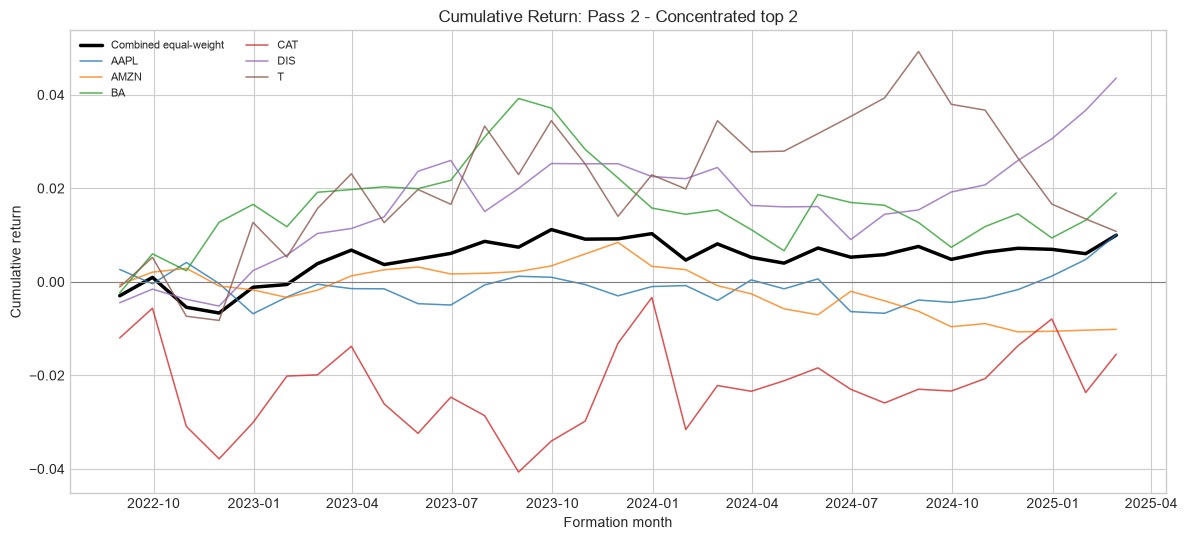

In [15]:
cumulative = combined_returns[["DATE", "portfolio_return"]].copy()
cumulative["combined"] = (1 + cumulative["portfolio_return"]).cumprod() - 1

issuer_cum = issuer_month_returns.pivot(index="DATE", columns="company_symbol", values="portfolio_return").sort_index()
issuer_cum = (1 + issuer_cum).cumprod() - 1

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(cumulative["DATE"], cumulative["combined"], color="black", linewidth=2.5, label="Combined equal-weight")
for issuer in issuer_cum.columns:
    ax.plot(issuer_cum.index, issuer_cum[issuer], linewidth=1.1, alpha=0.8, label=issuer)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"Cumulative Return: {SELECTED_TRIAL}")
ax.set_xlabel("Formation month")
ax.set_ylabel("Cumulative return")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## Turnover and DV01 Neutrality Checks

The first-order hedge is verified in both duration-contribution units and dollars of DV01 for `$1,000,000` gross capital. Values near zero are expected up to floating-point precision. Gross DV01 is nonzero; the purpose of the long-short scaling is to make the signed net DV01 approximately zero.

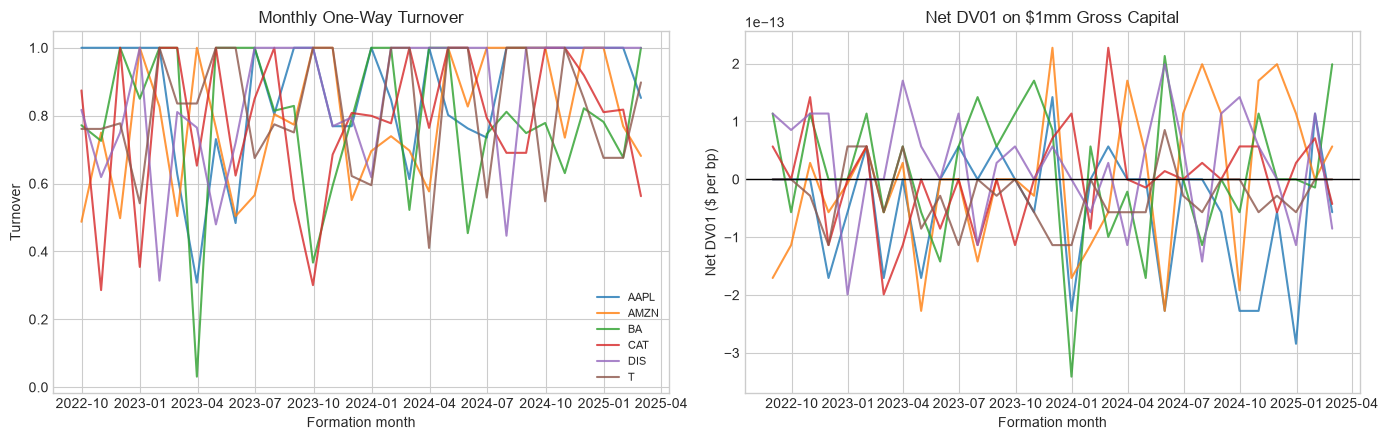

,max_abs_net_dv01_usd,avg_abs_net_dv01_usd,avg_gross_dv01_usd,avg_turnover
company_symbol,,,,
AAPL,$0.000000,$0.000000,"$1,531",0.87
AMZN,$0.000000,$0.000000,"$1,497",0.79
BA,$0.000000,$0.000000,"$1,075",0.79
CAT,$0.000000,$0.000000,"$1,115",0.79
DIS,$0.000000,$0.000000,"$1,121",0.86
T,$0.000000,$0.000000,"$1,015",0.82


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[0].plot(g["DATE"], g["turnover"], alpha=0.8, label=issuer)
axes[0].set_title("Monthly One-Way Turnover")
axes[0].set_xlabel("Formation month")
axes[0].set_ylabel("Turnover")
axes[0].legend(fontsize=8)

for issuer, g in issuer_month_returns.groupby("company_symbol"):
    axes[1].plot(g["DATE"], g["net_dv01_usd"], alpha=0.8, label=issuer)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Net DV01 on $1mm Gross Capital")
axes[1].set_xlabel("Formation month")
axes[1].set_ylabel("Net DV01 ($ per bp)")

fig.tight_layout()
plt.show()

display(
    issuer_month_returns.groupby("company_symbol").agg(
        max_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().max()),
        avg_abs_net_dv01_usd=("net_dv01_usd", lambda x: x.abs().mean()),
        avg_gross_dv01_usd=("gross_dv01_usd", "mean"),
        avg_turnover=("turnover", "mean"),
    ).style.format({
        "max_abs_net_dv01_usd": "${:,.6f}", "avg_abs_net_dv01_usd": "${:,.6f}",
        "avg_gross_dv01_usd": "${:,.0f}", "avg_turnover": "{:.2f}",
    })
)

## Outlier Check

A bond can sit away from an issuer curve without offering a clean convergence trade for several reasons: low liquidity, small issue size, age, coupon structure, optionality, seniority, and differences between the named issuer and the legal issuing entity. The first table identifies bonds that appear repeatedly in the selected portfolio. The second compares those observations with bonds that were not selected.

This is a descriptive check, not a causal test. If the cheap bonds are consistently smaller or less liquid, part of the residual may be compensation for trading difficulty rather than free alpha.

In [17]:
selection_review = (
    positions.assign(
        cheap_count=lambda x: (x["side"] == "long cheap").astype(int),
        rich_count=lambda x: (x["side"] == "short rich").astype(int),
        abs_resid_bps=lambda x: x["resid_bps"].abs(),
    )
    .groupby(["company_symbol", "CUSIP", "BOND_TYPE", "MATURITY", "COUPON"])
    .agg(
        times_selected=("ISSUE_ID", "size"),
        times_cheap=("cheap_count", "sum"),
        times_rich=("rich_count", "sum"),
        avg_duration=("DURATION", "mean"),
        avg_spread_bps=("T_Spread_bps", "mean"),
        avg_abs_resid_bps=("abs_resid_bps", "mean"),
        median_dvolume=("T_DVolume_num", "median"),
        median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
        avg_bond_age_years=("bond_age_years", "mean"),
    )
    .reset_index()
    .sort_values(["times_selected", "avg_abs_resid_bps"], ascending=False)
    .head(20)
)
display(selection_review)

fitted_review = fitted[fitted["fit_ok"]].copy()
selected_keys = positions[["company_symbol", "DATE", "ISSUE_ID", "side"]].drop_duplicates()
fitted_review = fitted_review.merge(selected_keys, on=["company_symbol", "DATE", "ISSUE_ID"], how="left")
fitted_review["selection_group"] = fitted_review["side"].fillna("not selected")

characteristic_comparison = fitted_review.groupby("selection_group").agg(
    observations=("ISSUE_ID", "size"),
    median_abs_residual_bps=("resid_bps", lambda x: x.abs().median()),
    median_dollar_volume=("T_DVolume_num", "median"),
    median_amount_outstanding=("AMOUNT_OUTSTANDING", "median"),
    median_bond_age_years=("bond_age_years", "median"),
    median_duration=("DURATION", "median"),
    median_tmt=("TMT", "median"),
    median_coupon=("COUPON", "median"),
)
display(characteristic_comparison)

,company_symbol,CUSIP,BOND_TYPE,MATURITY,COUPON,times_selected,times_cheap,times_rich,avg_duration,avg_spread_bps,avg_abs_resid_bps,median_dvolume,median_amount_outstanding,avg_bond_age_years
109,DIS,25468PCX2,CMTN,2042-12-01,3.7000,18,5,13,12.6883,21.5556,29.4470,"4,582,127.0000","500,000.0000",10.9004
77,CAT,149123BL4,CDEB,2035-09-15,5.3000,18,14,4,8.5994,38.8889,21.3598,"3,689,796.5000","307,320.0000",18.4315
45,AMZN,023135CK0,CDEB,2062-04-13,4.1000,17,9,8,17.2924,40.4118,13.6451,"71,928,799.0000","1,250,000.0000",1.5350
81,CAT,149123CD1,CDEB,2044-05-15,4.3000,16,7,9,12.9644,35.3125,27.7678,"10,679,450.0000","500,000.0000",9.4526
78,CAT,149123BN0,CDEB,2036-08-15,6.0500,16,14,2,8.8544,47.3750,25.3280,"16,683,649.5000","460,060.0000",17.3836
136,T,00209AAF3,CDEB,2031-03-01,8.7500,15,1,14,5.2713,17.4000,34.6224,"836,004.0000","228,894.0000",22.5148
82,CAT,149123CE9,CDEB,2064-05-15,4.7500,15,3,12,16.8687,28.3333,23.0447,"6,476,990.0000","500,000.0000",9.6500
76,CAT,149123BJ9,CDEB,2031-05-01,7.3000,14,9,5,5.7114,44.2857,33.9108,"760,367.0000","242,226.0000",22.6170
20,AAPL,037833EK2,CDEB,2051-08-05,2.7000,14,1,13,16.9157,24.7143,13.6131,"56,964,407.0000","1,800,000.0000",2.3149
44,AMZN,023135CJ3,CDEB,2052-04-13,3.9500,14,3,11,15.6257,26.0714,8.6117,"200,413,264.0000","2,500,000.0000",1.7393


,observations,median_abs_residual_bps,median_dollar_volume,median_amount_outstanding,median_bond_age_years,median_duration,median_tmt,median_coupon
selection_group,,,,,,,,
long cheap,372,27.2392,"17,578,816.5000","500,000.0000",6.3039,12.6800,20.2350,4.2500
not selected,6814,4.1810,"50,222,070.0000","1,100,000.0000",4.3039,7.1050,8.7100,3.6500
short rich,372,15.4680,"21,082,954.5000","758,680.0000",4.6790,13.6600,24.2550,4.1000


## Conclusion

The most important result is the data-quality check, not the attempt to maximize the backtest. Once the isolated Apple mark is removed before curve fitting and return construction, the apparent 2025 jump disappears. The three portfolio designs retain small positive gross returns, but turnover costs overwhelm all of them. The residual framework is therefore best treated as a useful research tool rather than evidence of a profitable strategy in this sample.

In [18]:
combined = summary_table.loc["combined"]
baseline = trial_summary.loc["Pass 1 - Baseline top 3"]
concentrated = trial_summary.loc["Pass 2 - Concentrated top 2"]
liquidity_aware = trial_summary.loc["Pass 3 - Liquidity-aware top 3"]
raw_baseline = raw_trial_summary.loc["Pass 1 - Baseline top 3"]
raw_concentrated = raw_trial_summary.loc["Pass 2 - Concentrated top 2"]
raw_liquidity = raw_trial_summary.loc["Pass 3 - Liquidity-aware top 3"]
best_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmax()
worst_issuer = issuer_summary["annualized_sharpe"].astype(float).idxmin()
avg_net_dv01 = issuer_month_returns["net_dv01_usd"].abs().mean()
avg_turnover = issuer_month_returns["turnover"].mean()
ret_source_share = filtered["next_return_source"].value_counts(normalize=True).to_dict()
ret_eom_share = ret_source_share.get("RET_EOM", 0.0)
cost_25 = cost_sensitivity.loc["25 bps"]
without_aapl = robustness_table.loc["Excluding AAPL"]

outlier_liquidity = characteristic_comparison.loc[
    [x for x in ["long cheap", "short rich", "not selected"] if x in characteristic_comparison.index],
    "median_dollar_volume",
]
liquidity_sentence = "The outlier table gives a bond-level check on whether the signal is tied to liquidity."
if {"long cheap", "not selected"}.issubset(outlier_liquidity.index):
    direction = "lower" if outlier_liquidity["long cheap"] < outlier_liquidity["not selected"] else "higher"
    liquidity_sentence = f"The long-cheap observations have {direction} median dollar volume than the non-selected observations, so liquidity still appears to be part of the signal."

excluded = price_mark_exclusions.iloc[0]
finding_text = f"""
### Effect of the Price-Quality Correction

The sample covers AAPL, AMZN, BA, CAT, DIS, and T from {START_DATE} through {END_DATE}. Before calculating returns or fitting curves, an isolated-mark check is applied to adjacent monthly prices. It flags one observation: {excluded['company_symbol']} CUSIP `{excluded['CUSIP']}` on {excluded['DATE']:%Y-%m-%d}, with prices of {excluded['previous_price_qc']:.2f}, {excluded['PRICE_EOM']:.2f}, and {excluded['next_price_qc']:.2f} across the three surrounding month-ends.

Removing that mark changes the portfolio comparison. Pass 1 earns {baseline['gross_annualized_return']:.2%} gross, Pass 2 earns {concentrated['gross_annualized_return']:.2%}, and Pass 3 earns {liquidity_aware['gross_annualized_return']:.2%}. The unfiltered versions reported {raw_baseline['gross_annualized_return']:.2%}, {raw_concentrated['gross_annualized_return']:.2%}, and {raw_liquidity['gross_annualized_return']:.2%}. The difference indicates that the earlier headline result was primarily a data-quality artifact rather than a stable portfolio improvement.

Pass 2 has the strongest cleaned gross Sharpe ratio at {concentrated['gross_sharpe']:.2f}, and is selected as the specification for further discussion. Its gross total return is {combined['total_return']:.2%}, annualized return is {combined['annualized_return']:.2%}, annualized volatility is {combined['annualized_volatility']:.2%}, and annualized Sharpe ratio is {combined['annualized_sharpe']:.2f}. Average one-way monthly turnover is {avg_turnover:.2f}. With a 25 bp one-way cost, annualized return falls to {cost_25['annualized_return']:.2%} and Sharpe falls to {cost_25['annualized_sharpe']:.2f}. On the $1 million gross-capital convention, the sum of monthly gross PnL is ${combined['total_pnl_usd']:,.0f}.

The hedge behaves as intended: average absolute net DV01 is ${avg_net_dv01:,.6f} per basis point. Among the six issuers, {best_issuer} has the strongest result and {worst_issuer} the weakest. {liquidity_sentence}

The overall conclusion is conservative. The issuer-curve residual organizes relative-value opportunities, but the cleaned sample provides no evidence that the strategy survives plausible transaction costs. A stronger follow-up would use independently validated month-end prices, freeze the portfolio rule on an earlier training sample, and evaluate it on untouched later observations.

{ret_eom_share:.1%} of cleaned bond-month observations have a valid next-month WRDS `RET_EOM`. The price-plus-accrual fallback was available but was not required in this sample.
"""

display(Markdown(finding_text))


### Effect of the Price-Quality Correction

The sample covers AAPL, AMZN, BA, CAT, DIS, and T from 2022-08-31 through 2025-03-31. Before calculating returns or fitting curves, an isolated-mark check is applied to adjacent monthly prices. It flags one observation: AAPL CUSIP `037833BX7` on 2025-02-28, with prices of 91.76, 25.17, and 92.24 across the three surrounding month-ends.

Removing that mark changes the portfolio comparison. Pass 1 earns 0.15% gross, Pass 2 earns 0.39%, and Pass 3 earns 0.10%. The unfiltered versions reported 2.75%, 4.48%, and 5.99%. The difference indicates that the earlier headline result was primarily a data-quality artifact rather than a stable portfolio improvement.

Pass 2 has the strongest cleaned gross Sharpe ratio at 0.38, and is selected as the specification for further discussion. Its gross total return is 1.00%, annualized return is 0.39%, annualized volatility is 1.02%, and annualized Sharpe ratio is 0.38. Average one-way monthly turnover is 0.82. With a 25 bp one-way cost, annualized return falls to -1.98% and Sharpe falls to -1.96. On the $1 million gross-capital convention, the sum of monthly gross PnL is $10,067.

The hedge behaves as intended: average absolute net DV01 is $0.000000 per basis point. Among the six issuers, DIS has the strongest result and AMZN the weakest. The long-cheap observations have lower median dollar volume than the non-selected observations, so liquidity still appears to be part of the signal.

The overall conclusion is conservative. The issuer-curve residual organizes relative-value opportunities, but the cleaned sample provides no evidence that the strategy survives plausible transaction costs. A stronger follow-up would use independently validated month-end prices, freeze the portfolio rule on an earlier training sample, and evaluate it on untouched later observations.

95.6% of cleaned bond-month observations have a valid next-month WRDS `RET_EOM`. The price-plus-accrual fallback was available but was not required in this sample.


## Main Assumptions and Limitations

- **Price-quality screen:** the main analysis removes an isolated month-end mark when it differs by more than 40% from both adjacent monthly prices and those neighboring prices remain within 20% of one another. This two-sided check is an ex-post data-validation rule, not an investable signal. The unfiltered results are reported as a sensitivity.
- **Return measure:** WRDS `RET_EOM` is used as the monthly total return. The fallback adds clean-price return and accrued coupon using actual gap days over 360, but it does not rebuild the full coupon schedule.
- **Timing:** the remaining month-end fields are assumed to have been available when the position was formed. Publication delays and later revisions are not modeled.
- **Curve model:** the three-factor regression is transparent and satisfies the three-parameter specification, but it is not a full Nelson-Siegel cash-flow model and does not rebuild the Treasury zero curve.
- **Bond features:** seniority, rating, default status, convertibility, maturity, and issue size are controlled for. Complete call schedules, 144A status, subsidiary distinctions, insurance, and step-up coupons are not available in the supplied files.
- **Risk hedge:** the portfolio neutralizes first-order parallel-rate DV01. It can still carry Treasury-curve slope and curvature risk, spread-duration risk, issuer beta, downgrade risk, and liquidity exposure.
- **Trading costs:** the turnover-based cost cases are approximations. Actual bid-offer spreads, market impact, financing, borrow fees, and failed fills may be higher and may differ between buys and shorts.
- **Model selection:** three portfolio rules are tested and the best one is selected on this sample. That introduces selection bias even though the cleaned winner is weak. A cleaner test would choose the rule on an earlier training period and evaluate it on later data.
- **Shorting:** some corporate bonds are expensive or impossible to borrow. The long-short backtest is a research exercise, not proof that every trade could have been executed.